# Autoencoder

librerias

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Reshape
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Carga dataset Fashion MNIST

In [2]:
#

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
class_names = np.array(['T-shirt/top', 'Trouser/pants', 'Pullover shirt', 'Dress',
                        'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag','Ankle boot'])

Muestra un par de instancias

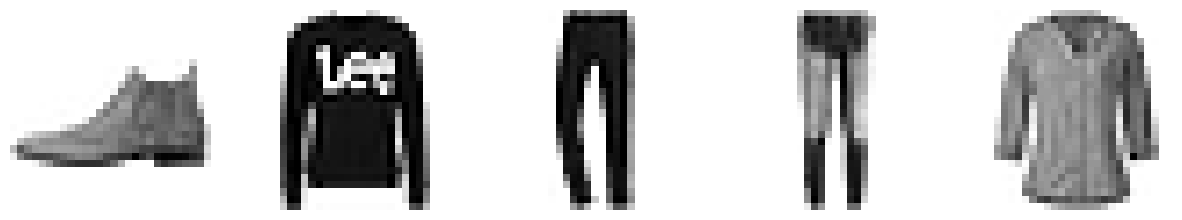

In [3]:
#

n_examples = 1000
example_images = x_test[0:n_examples]
example_labels = y_test[0:n_examples]

f, axs = plt.subplots(1, 5, figsize=(15, 4))
for j in range(len(axs)):
    axs[j].imshow(example_images[j], cmap='binary')
    axs[j].axis('off')

Encoder

In [4]:
#

encoded_dim  = 2

encoder = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(256, activation= "sigmoid"),
    Dense(128, activation= "sigmoid"),
    Dense(64, activation= "sigmoid"),
    Dense(encoded_dim)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Prueba el decoder solo antes de entrenar, para ver variables lantentes sin aprendizaje.

In [5]:
#

pretrain_example_encodings = encoder(example_images).numpy()
pretrain_example_encodings

array([[-0.42078084, -0.35271943],
       [-0.43012226, -0.3620664 ],
       [-0.42974153, -0.3452031 ],
       ...,
       [-0.4385917 , -0.34461662],
       [-0.4356788 , -0.35145083],
       [-0.43482858, -0.34631154]], dtype=float32)

Grafica las variables latentes sin aprendizaje (aleatorias)

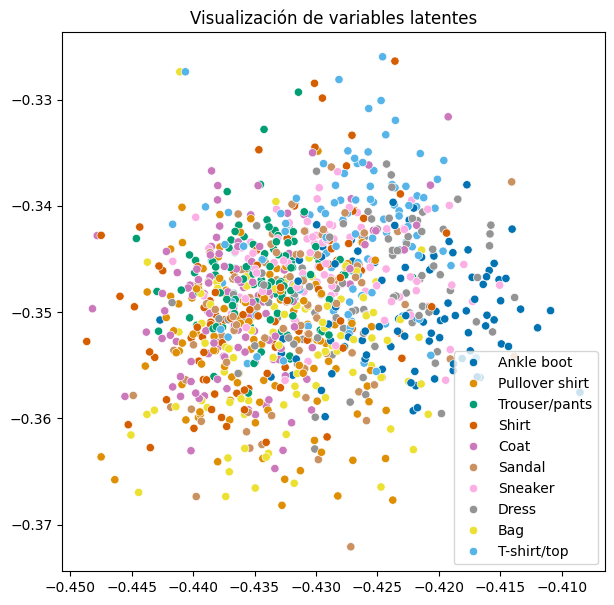

In [6]:
#

f, ax = plt.subplots(1, 1, figsize=(7, 7))
sns.scatterplot(x = pretrain_example_encodings[:, 0],
                y = pretrain_example_encodings[:, 1],
                hue=class_names[example_labels], ax=ax,
                palette=sns.color_palette("colorblind", 10));
ax.set_title('Visualización de variables latentes');

Decoder

In [7]:
#

decoder = Sequential([
    Dense(64, activation= "sigmoid", input_shape = (encoded_dim,)),
    Dense(128, activation= "sigmoid"),
    Dense(256, activation= "sigmoid"),
    Dense((28*28), activation= "sigmoid"), #for the flatten
    Reshape((28, 28))
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Integración de la arquitectura en autoencoder

In [8]:
#

autoencoder = Model(inputs = encoder.inputs, outputs = decoder(encoder.outputs))
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │       243,024 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,266 (1.85 MB)

 Trainable params: 485,266 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

Comlpilación y Fit del autoencoder, todo entrena junto.

In [9]:

#
autoencoder.compile(loss="binary_crossentropy")

#
autoencoder.fit(x = x_train, y = x_train, epochs = 30, batch_size = 32)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6
Received: inputs=['Tensor(shape=(32, 2))']
  warnings.warn(msg)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4984
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4904
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.4905
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4908
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4907
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.4905
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4901
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4901
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4901
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4908
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4901
Epoch 12/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.4891
Epoch 13/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.4331
Epoch 14/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.4220
Epoch 15/30
1875/1875 ━━━━━━━━━━━━━━━━━━

Solo econder para generar variables latentes

In [10]:
#

posttrain_example_encodings = encoder(example_images).numpy()
posttrain_example_encodings

array([[ 2.5344472 ,  2.3412578 ],
       [-2.9975429 , -0.28256235],
       [-1.6768471 , -8.49792   ],
       ...,
       [-3.6633496 ,  1.5063119 ],
       [ 8.165651  ,  2.672228  ],
       [ 5.2959094 ,  2.6573331 ]], dtype=float32)

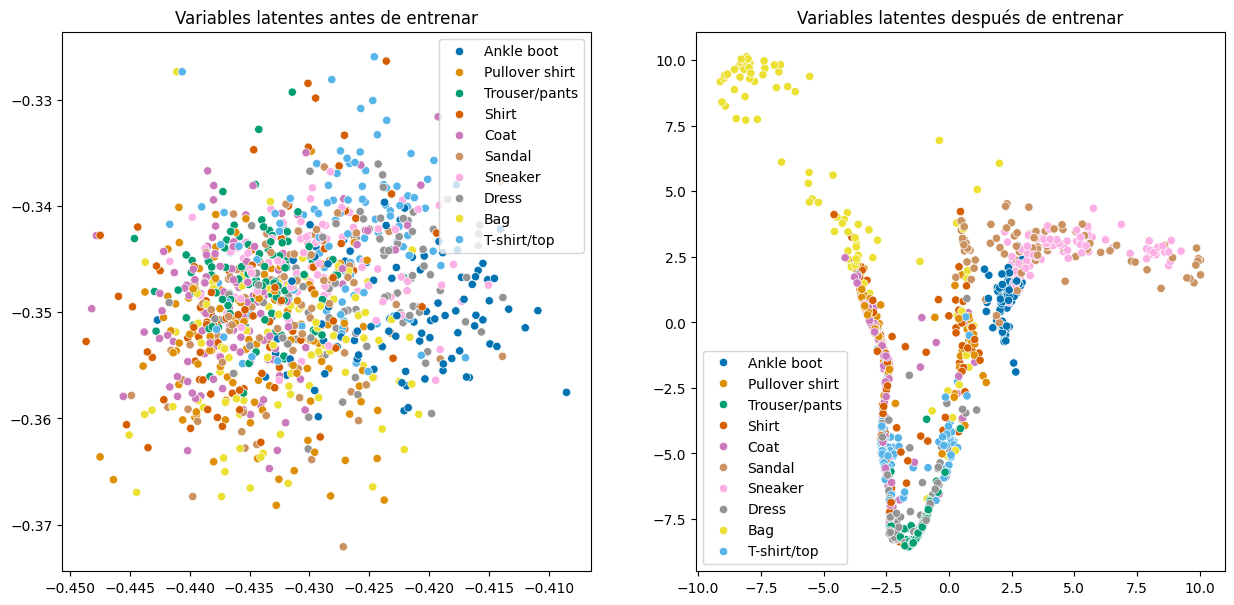

In [11]:
#

f, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
sns.scatterplot(x = pretrain_example_encodings[:, 0],
                y = pretrain_example_encodings[:, 1],
                hue=class_names[example_labels], ax=axs[0],
                palette=sns.color_palette("colorblind", 10))

sns.scatterplot(x = posttrain_example_encodings[:, 0],
                y = posttrain_example_encodings[:, 1],
                hue=class_names[example_labels], ax=axs[1],
                palette=sns.color_palette("colorblind", 10))


axs[0].set_title('Variables latentes antes de entrenar');
axs[1].set_title('Variables latentes después de entrenar');

Autoencoder completo para reconstrucción de imágenes.

In [12]:
#

reconstructed_example_images = autoencoder(example_images)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1000, 28, 28))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6
Received: inputs=['Tensor(shape=(1000, 2))']
  warnings.warn(msg)


In [13]:
reconstructed_example_images = decoder(posttrain_example_encodings)

Comparación de instación vs reconstruido donde se eliminan la marcas de la ropa(eliminación de ruido)

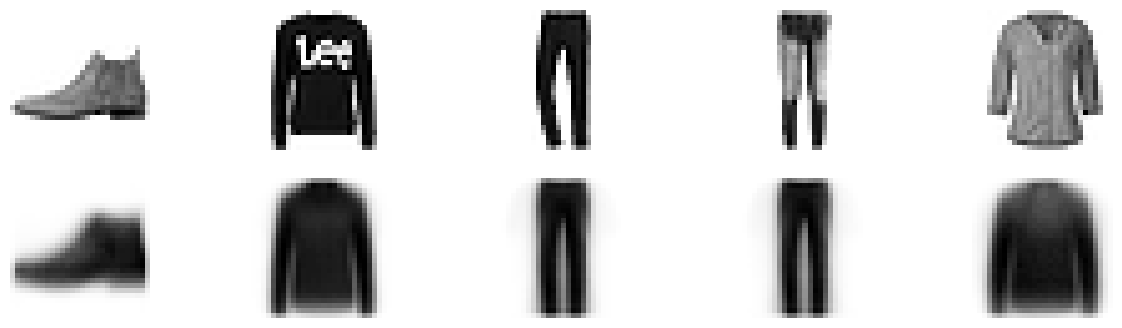

In [14]:
#
f, axs = plt.subplots(2, 5, figsize=(15, 4))
for j in range(5):
    axs[0, j].imshow(example_images[j], cmap='binary')
    axs[1, j].imshow(reconstructed_example_images[j].numpy().squeeze(), cmap='binary')
    axs[0, j].axis('off')
    axs[1, j].axis('off')

Solo Decoder, un arreglo de números aleatorios (variables latentes), se usa para crear imágenes.

In [15]:
#
posttrain_example_encodings
random_encodings = np.array([[1,1],
                            [2 ,-2],
                            [3 ,-3],
                            [4 ,4],
                            [5, 1]])

reconstructed_example_images = decoder(random_encodings)

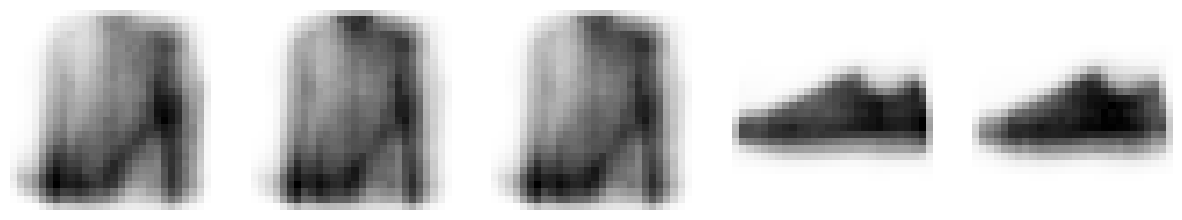

In [16]:
f, axs = plt.subplots(1, 5, figsize=(15, 4))
for j in range(5):
    axs[j].imshow(reconstructed_example_images[j].numpy().squeeze(), cmap='binary')
    axs[j].axis('off')